# Synthetic Data

In [13]:
import os 
import numpy as np
from package import *
save_path = os.getcwd() + '\\' + 'image' + '\\' + 'simulation'+ '\\'

### An example to generate comparison graph 

$n$ is the number of items <br>
$N$ is the number of comparison (function of $n$) <br>
$v$ is the covariates' coeffecient<br>
$[m_{lower}, m_{upper})$ is the interval of all possible edge size.

In [14]:
n = 200
N = lambda n: int(n*(n-1)/2)
v = [1,-0.5,0]
d = len(v)
m_lower = 2
m_upper = 3
H = generator.MultipleComparison(n,N,v,m_lower=m_lower,m_upper=m_upper)

complete get edges: Num_Edges=19900, Num_Nodes = 200,m_lower = 2,m_upper = 2


H.T, H.X are two lists containing corresponding item index and covariates.

In [15]:
print(H.T)

[[99, 77], [77, 32], [140, 96], [148, 0], [195, 186], [152, 133], [82, 71], [82, 3], [77, 145], [1, 37], [171, 3], [190, 4], [16, 177], [32, 60], [51, 23], [98, 191], [133, 14], [170, 109], [90, 89], [111, 158], [69, 8], [37, 169], [95, 115], [155, 195], [110, 74], [151, 133], [189, 107], [141, 92], [161, 151], [173, 165], [193, 41], [47, 141], [187, 43], [104, 48], [22, 10], [132, 71], [161, 99], [90, 38], [136, 185], [36, 60], [94, 89], [113, 5], [48, 133], [182, 153], [166, 147], [92, 139], [10, 0], [135, 111], [148, 149], [87, 148], [56, 92], [87, 58], [97, 69], [79, 147], [66, 6], [130, 163], [183, 68], [12, 53], [136, 110], [137, 180], [57, 193], [168, 37], [125, 177], [34, 76], [135, 183], [104, 175], [59, 145], [182, 25], [18, 106], [59, 20], [98, 40], [136, 81], [80, 195], [125, 179], [196, 41], [196, 25], [31, 52], [74, 89], [176, 129], [73, 135], [112, 32], [174, 0], [13, 55], [44, 171], [48, 188], [189, 121], [56, 106], [66, 96], [155, 20], [78, 91], [101, 146], [76, 26], [

##### Estimation

Set ''detail = True'' to see the details of alternating method. <br>
We develop an algorithm (type='pair') to improve the velocity of pairwise case.

In [16]:
detail = True
u_estimation, v_estimation = algorithm.AM(H.T,H.X,n,detail=detail,type = 'pair')

-----1-----
log-likelihood: -0.693147180560086
u iterative times: 9
v iterative times: 7 and v = [ 0.96329497 -0.47308765  0.01327576]
-----2-----
log-likelihood: -0.5126204672203258
u iterative times: 7
v iterative times: 5 and v = [ 0.98460232 -0.4842948   0.01349321]
-----3-----
log-likelihood: -0.5100518854520008
u iterative times: 2
v iterative times: 4 and v = [ 0.985679   -0.4848602   0.01351626]
u iterative times: 2


In [17]:
detail = True
u_estimation, v_estimation = algorithm.AM(H.T,H.X,n,d,detail=detail,type = 'multi')

-----1-----
log-likelihood: -0.693147180560086
u iterative times: 9
v iterative times: 6 and v = [ 0.95013181 -0.46511115  0.01208291]
-----2-----
log-likelihood: -0.5126427603657665
u iterative times: 7
v iterative times: 4 and v = [ 0.96329497 -0.47308765  0.01327576]
-----3-----
log-likelihood: -0.51011207053357
u iterative times: 2
v iterative times: 4 and v = [ 0.98412711 -0.48402441  0.01347548]


##### Error bound

In [18]:
u_true, v_true = H.u,H.v
u_infty = max(abs(u_estimation-u_true))
v_infty = max(abs(v_estimation-v_true))

print(f'u_infty:{u_infty}')
print(f'v_infty:{v_infty}')

u_infty:0.4460719121083002
v_infty:0.01499036115718988


### Simulation study in the supplement B.1

In simulation part, we will set repeat_time = 300.

In [19]:
repeat_time = 1 ### set 300
n = [200,400,600,800,1000]
v = [1,-0.5,0]

##### NURHM

In [20]:

N = lambda n: int(0.1*n*(np.log(n))**3)
m_lower = 2
m_upper = 8
simulation(n, N, v, m_lower, m_upper, repeat_time = repeat_time,name = 'NURHM')

----------
complete get edges: Num_Edges=2974, Num_Nodes = 200,m_lower = 2,m_upper = 7
[[41, 11, 185, 48], [58, 126, 122, 67, 8, 52, 94], [18, 169, 164], [33, 14, 170, 49, 100], [61, 21, 15, 191], [189, 20, 58, 170, 178], [177, 70, 87, 169, 161], [187, 196, 143, 175], [193, 120, 94, 151, 66, 143, 84], [132, 9, 94, 37], [139, 103, 42], [74, 36, 138], [145, 152, 8], [27, 121, 110], [143, 175, 35, 181, 68, 153], [196, 71, 16, 36, 126, 66, 89], [82, 166, 6, 162, 173, 168], [87, 0, 40, 107], [162, 122, 49, 77, 86, 102], [189, 45, 53, 142, 186, 1, 161], [144, 185, 108, 20, 24, 33, 62], [145, 93, 11, 19, 34, 167], [9, 171, 175, 38], [191, 146, 103, 18, 165, 61], [112, 199, 107, 113, 99, 104], [81, 138, 7, 107, 195, 121, 54], [116, 13, 117], [105, 99, 60, 20, 2, 49], [170, 119], [146, 14, 156, 9, 0, 15, 136], [14, 92, 155], [87, 53, 193], [18, 127, 11, 72, 101, 197], [50, 101, 63, 189], [144, 65, 157], [67, 79, 96, 117, 131, 93], [186, 111, 31, 188], [94, 47, 179, 12, 153, 175], [138, 157, 53,

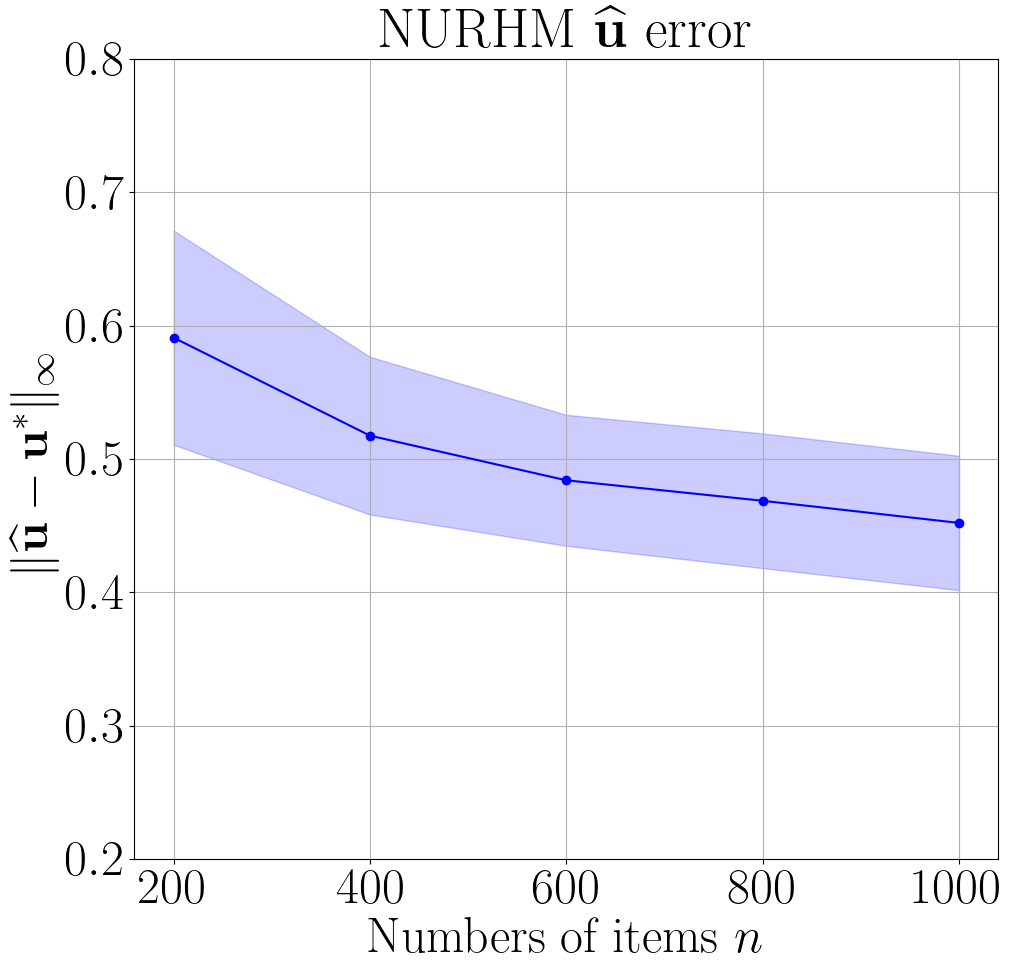

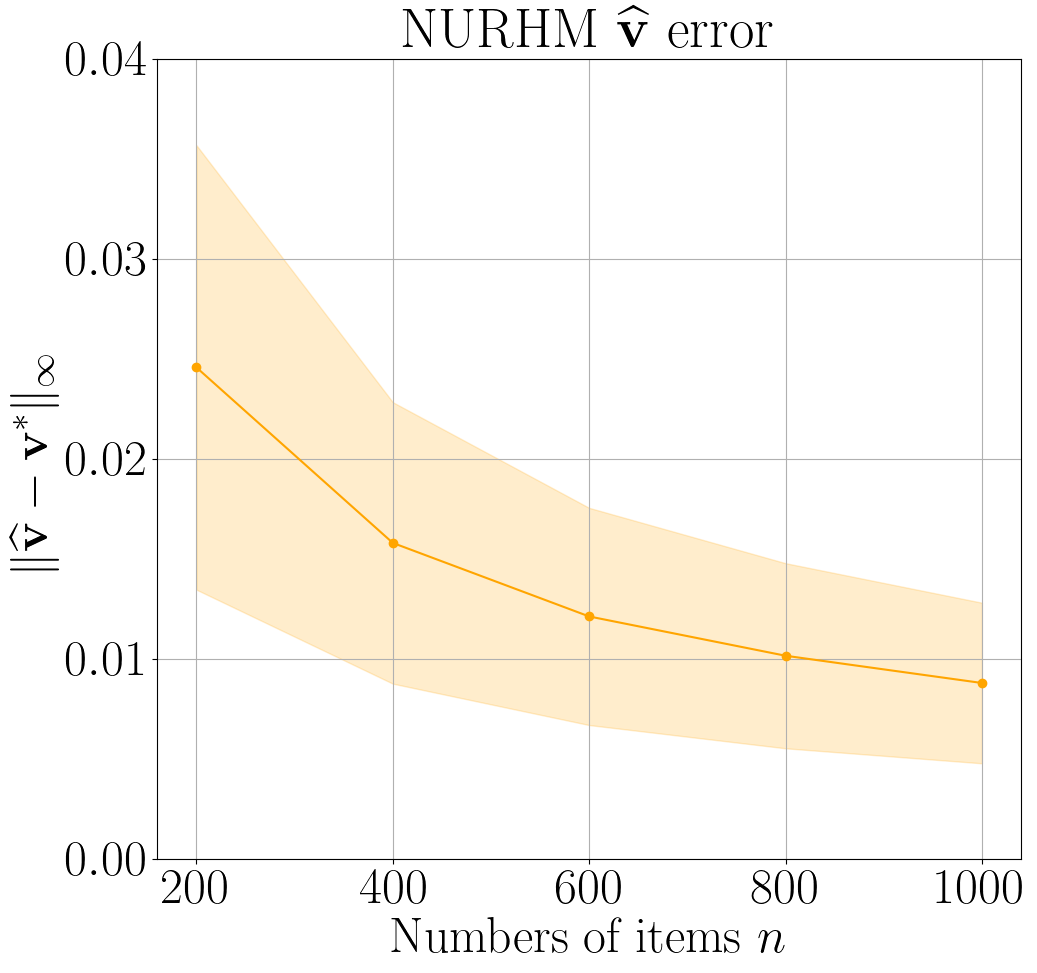

In [21]:
basicfun.plot('NURHM',save_path)

##### HSBM

In [22]:
N = lambda n: int(0.07*n**2)
m_lower = 5
m_upper = 6
simulation(n, N, v, m_lower, m_upper, repeat_time = repeat_time,name = 'HSBM')

----------
complete get edges: Num_Edges=2800, Num_Nodes = 200,m_lower = 5,m_upper = 5
[[83, 79, 88, 125, 117], [27, 90, 100, 157, 108], [101, 98, 93, 106, 144], [132, 190, 67, 96, 121], [161, 171, 69, 160, 141], [159, 80, 174, 128, 75], [91, 79, 143, 73, 96], [182, 183, 148, 161, 130], [89, 192, 128, 180, 98], [77, 71, 90, 97, 160], [78, 131, 117, 142, 80], [86, 153, 99, 173, 162], [24, 64, 63, 54, 29], [137, 110, 81, 181, 190], [197, 107, 189, 133, 191], [115, 148, 153, 149, 194], [170, 176, 165, 198, 189], [115, 156, 79, 166, 180], [44, 0, 43, 50, 25], [183, 128, 96, 164, 125], [109, 164, 72, 100, 186], [47, 56, 19, 18, 49], [50, 17, 21, 48, 2], [43, 29, 27, 47, 23], [142, 156, 115, 163, 85], [119, 72, 166, 120, 186], [122, 163, 66, 93, 169], [159, 152, 99, 143, 95], [48, 95, 111, 84, 60], [11, 12, 13, 59, 9], [180, 198, 90, 137, 178], [167, 197, 126, 96, 119], [128, 163, 102, 192, 124], [123, 177, 149, 116, 117], [82, 177, 170, 168, 162], [85, 191, 99, 132, 184], [136, 180, 173, 14

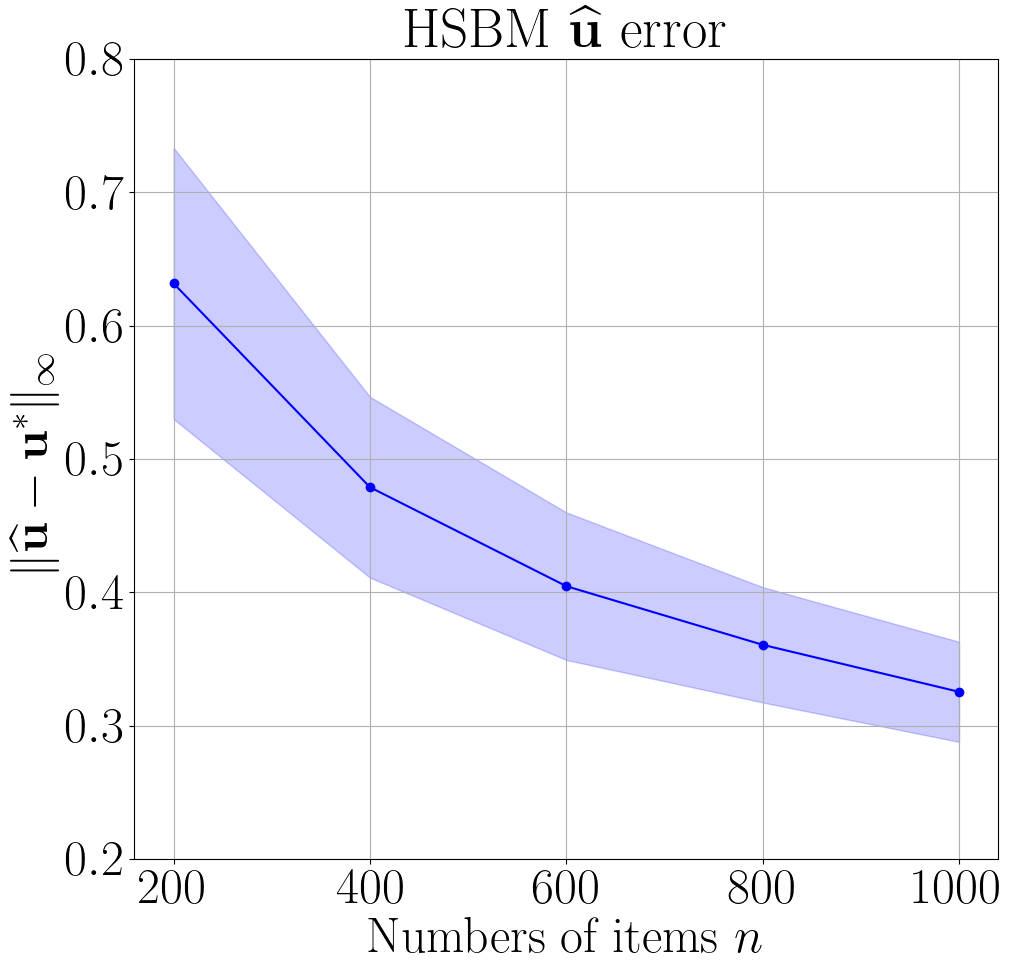

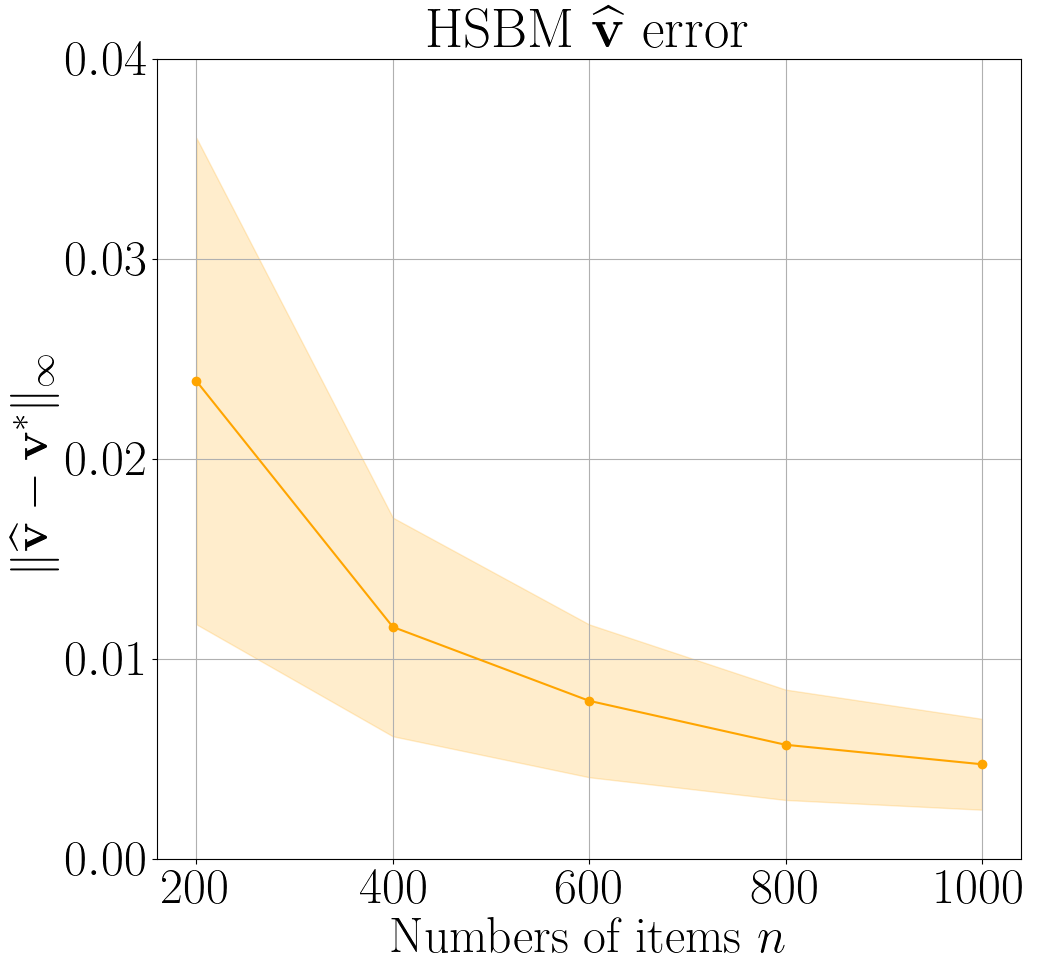

In [23]:
basicfun.plot('HSBM',save_path)